# 13 — Análisis exploratorio de variables: Liga MX (7 temporadas, dataset actualizado a septiembre 2026)

Este notebook arranca desde la versión **v3**, la más reciente que pasaste
(`matches_ligamx_2020_2025_v3_arbitraje.csv`, copiada a `data/processed/` desde tu archivo en
Desktop) — esta es ahora la fuente única para toda esta secuencia de notebooks (13 y 14 en
adelante), reemplazando a la v2 que se usaba antes aquí.

Diferencia con el CSV original del pipeline de scraping (ver `12_pipeline_comportamiento_ligamx.ipynb`,
Fase 9): esta versión ya no trae `round`, `attendance`, `match_report_url`, `match_id`, `notes`, ni
las columnas redundantes `home_team_stats`/`away_team_stats` — y sí agrega columnas derivadas que
construiste en Numbers: `home_efficency`/`away_efficency` (tiros a puerta / tiros totales),
`home_total_cards`/`away_total_cards`/`total_game_cards`, y
`home_card_game_per_fouls`/`away_card_game_per_foul`. En total quedan **41 columnas**.

**Actualización (Fase 11, septiembre 2026):** el archivo v3 se extendió con las temporadas 2025-2026 (completa) y 2026-2027 (Apertura en curso) — de 1,706 a **2,102 partidos**, de 18 a **19 equipos** (se sumó Atlante, recién ascendido) y de 46 a **53 nombres de árbitro crudos** (45 reales tras consolidar 8 pares duplicados por el mismo problema de formato de FBref, ver la celda de corrección justo abajo).

**Objetivo de este notebook:** construir el diccionario de variables, revisar calidad de datos
(faltantes, rangos, consistencia) y dejar una primera exploración descriptiva/de correlaciones.
Iremos ampliando el análisis por bloques, planteando cada siguiente paso conforme avancemos.

In [1]:
import pandas as pd
import numpy as np
import re

pd.set_option("display.max_columns", 50)

ruta = "../data/processed/matches_ligamx_2020_2025_v3_arbitraje.csv"
df = pd.read_csv(ruta, dtype=str)

print("Filas:", len(df))
print("Columnas:", len(df.columns))
df.head(3)

Filas: 2102
Columnas: 41


,gameweek,dayofweek,date,start_time,home_team,score,away_team,venue,referee,season,home_possession,away_possession,home_shots_on_target,home_shots_total,home_efficency,away_shots_on_target,away_shots_total,away_efficency,home_saves,home_saves_total,away_saves,away_saves_total,home_yellow,home_red,home_total_cards,away_yellow,away_red,away_total_cards,total_game_cards,home_fouls,home_card_game_per_fouls,away_fouls,away_card_game_per_foul,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides
0,1.0,Fri,2020-07-24,19:30,Necaxa,0–3,UANL,Estadio Victoria de Aguascalientes,Eduardo Basulto,2020-2021,40,60,1,8,0.125,5,17,0.294117647058824,2,5,1,1,1,0,1,1,0,1,2,14,0.142857142857143,17,0.117647058823529,4,6,11,17,9,3,2,1
1,1.0,Sat,2020-07-25,19:00 (21:00),Tijuana,3–1,Atlas,Estadio Caliente,César Arturo Ramos,2020-2021,56,44,5,13,0.384615384615385,4,8,0.5,3,4,2,5,2,0,2,3,1,4,6,14,0.428571428571429,15,0.4,1,6,11,13,10,14,1,0
2,1.0,Sat,2020-07-25,19:00,Guadalajara,0–0,León,Estadio Akron,Jorge Rojas,2020-2021,42,58,4,11,0.363636363636364,4,13,0.307692307692308,4,4,4,4,1,0,1,1,0,1,2,14,0.142857142857143,11,0.181818181818182,0,5,5,16,13,8,0,0


### Corrección de calidad de datos: nombres de árbitro duplicados

Igual que en el notebook 14: FBref cambió el formato de los nombres de árbitro a partir de
2023-24 (agregó acentos y/o segundo nombre), lo que dejó **8 árbitros duplicados** con dos
identidades distintas en la fuente. Se consolidan aquí, al inicio, para que todo el análisis de
este notebook (incluyendo `arbitro_dureza` más abajo) use la identidad correcta desde el
principio.

In [2]:
mapa_nombres_arbitro = {
    "Victor Caceres": "Víctor Cáceres",
    "Oscar Mejia": "Oscar Mejía",
    "Marco Ortíz": "Marco Antonio Ortíz",
    "Luis Santander": "Luis Enrique Santander",
    "Erick Miranda": "Erick Yair Miranda",
    "Guillermo Pacheco": "Guillermo Pacheco Larios",
    "Jesus Lopez": "Jesús López",
    "Ismael Lopez": "Ismael López",
}
print("Árbitros únicos antes de consolidar:", df["referee"].nunique())
df["referee"] = df["referee"].replace(mapa_nombres_arbitro)
print("Árbitros únicos después de consolidar:", df["referee"].nunique())

Árbitros únicos antes de consolidar: 53
Árbitros únicos después de consolidar: 45


In [3]:
# Tipado: separamos identificadoras/categóricas/fecha de las numéricas

columnas_numericas = [
    "gameweek",
    "home_possession", "away_possession",
    "home_shots_on_target", "home_shots_total", "home_efficency",
    "away_shots_on_target", "away_shots_total", "away_efficency",
    "home_saves", "home_saves_total",
    "away_saves", "away_saves_total",
    "home_yellow", "home_red", "home_total_cards",
    "away_yellow", "away_red", "away_total_cards", "total_game_cards",
    "home_fouls", "home_card_game_per_fouls",
    "away_fouls", "away_card_game_per_foul",
    "home_corners", "away_corners",
    "home_crosses", "away_crosses",
    "home_interceptions", "away_interceptions",
    "home_offsides", "away_offsides",
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["date"] = pd.to_datetime(df["date"], errors="coerce")

# score -> goles de local y visitante (maneja marcadores con penales tipo "(2) 2–2 (4)")
patron_score = r"(?:\(\d+\)\s*)?(\d+)\s*[\u2013-]\s*(\d+)(?:\s*\(\d+\))?"
goles = df["score"].str.extract(patron_score)
df["home_goals"] = pd.to_numeric(goles[0], errors="coerce")
df["away_goals"] = pd.to_numeric(goles[1], errors="coerce")

print("Partidos sin score interpretable:", df["home_goals"].isna().sum())
df[["date", "home_team", "score", "home_goals", "away_goals", "away_team"]].head(3)

Partidos sin score interpretable: 0


,date,home_team,score,home_goals,away_goals,away_team
0,2020-07-24,Necaxa,0–3,0,3,UANL
1,2020-07-25,Tijuana,3–1,3,1,Atlas
2,2020-07-25,Guadalajara,0–0,0,0,León


## Diccionario de variables

| Variable | Tipo | Descripción |
|---|---|---|
| `gameweek` | numérica discreta (ordinal por jornada) | Jornada del calendario dentro de la temporada (Apertura/Clausura combinados por FBref) |
| `dayofweek` | categórica nominal | Día de la semana en que se jugó |
| `date` | fecha | Fecha del partido |
| `start_time` | hora (texto HH:MM) | Hora de inicio |
| `home_team` | categórica nominal (alta cardinalidad) | Equipo local |
| `score` | texto (marcador crudo) | Marcador tal como lo reporta FBref; ya parseado en `home_goals`/`away_goals` |
| `away_team` | categórica nominal (alta cardinalidad) | Equipo visitante |
| `venue` | categórica nominal (alta cardinalidad) | Estadio sede |
| `referee` | categórica nominal (alta cardinalidad) | Árbitro central |
| `season` | categórica ordinal | Temporada (2020-2021 … 2024-2025) |
| `home_possession` / `away_possession` | continua (%, suman 100) | Posesión de balón |
| `home_shots_on_target` / `away_shots_on_target` | numérica de conteo | Tiros a puerta |
| `home_shots_total` / `away_shots_total` | numérica de conteo | Tiros totales |
| `home_efficency` / `away_efficency` *(derivada)* | continua [0,1] | Tiros a puerta / tiros totales |
| `home_saves` / `away_saves` | numérica de conteo | Atajadas del portero |
| `home_saves_total` / `away_saves_total` | numérica de conteo | Tiros a puerta recibidos por el portero (base para % atajadas) |
| `home_yellow` / `away_yellow` | numérica de conteo | Tarjetas amarillas |
| `home_red` / `away_red` | numérica de conteo | Tarjetas rojas (incluye roja directa por doble amarilla) |
| `home_total_cards` / `away_total_cards` *(derivada)* | numérica de conteo | Amarillas + rojas por equipo |
| `total_game_cards` *(derivada)* | numérica de conteo | Tarjetas totales del partido (ambos equipos) |
| `home_fouls` / `away_fouls` | numérica de conteo | Faltas cometidas |
| `home_card_game_per_fouls` / `away_card_game_per_foul` *(derivada, tal como venía en Numbers)* | continua | `total_game_cards` (ambos equipos) / faltas de ESE equipo — ojo: el numerador no es solo del equipo, mezcla las tarjetas del rival también |
| `home_card_per_foul_propio` / `away_card_per_foul_propio` *(derivada, corregida en este notebook)* | continua | `home_total_cards` / `home_fouls` (y análogo away) — versión puramente por equipo: tarjetas propias entre faltas propias |
| `home_corners` / `away_corners` | numérica de conteo | Tiros de esquina |
| `home_crosses` / `away_crosses` | numérica de conteo | Centros |
| `home_interceptions` / `away_interceptions` | numérica de conteo | Intercepciones |
| `home_offsides` / `away_offsides` | numérica de conteo | Fueras de lugar |
| `home_goals` / `away_goals` *(derivadas de `score`)* | numérica de conteo | Goles |

Nota: `team`, `referee`, `venue` son nominales de alta cardinalidad — no entran directo a una matriz
de correlación (ni Pearson ni policórica); si se quieren correlacionar hay que convertirlas primero
en una variable ordinal proxy (como hicimos con `dureza_arbitro` en el notebook 14).

In [4]:
# Calidad de datos: faltantes por columna

faltantes = df.isna().sum().sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]
faltantes.to_frame("faltantes")

,faltantes
gameweek,207
away_offsides,115
home_offsides,115
away_efficency,1
away_saves,1
home_saves_total,1
home_saves,1
away_saves_total,1


In [5]:
# Cobertura por temporada

df["season"].value_counts().sort_index()

season
2020-2021    342
2021-2022    342
2022-2023    342
2023-2024    340
2024-2025    340
2025-2026    337
2026-2027     59
Name: count, dtype: int64

In [6]:
# Consistencia posesión (home + away ≈ 100)

diff_posesion = (df["home_possession"] + df["away_possession"] - 100).abs()
print("Máxima desviación de 100% en posesión:", diff_posesion.max())
print("Partidos con desviación > 1 punto:", (diff_posesion > 1).sum())

Máxima desviación de 100% en posesión: 1
Partidos con desviación > 1 punto: 0


In [7]:
# Estadística descriptiva de las variables numéricas

variables_numericas_finales = columnas_numericas + ["home_goals", "away_goals"]
df[variables_numericas_finales].describe().T

,count,mean,std,min,25%,50%,75%,max
gameweek,1895.0,8.837995,4.918838,1.0,5.000000,9.000000,13.000000,17.000000
home_possession,2102.0,51.733111,10.506979,24.0,44.000000,52.000000,59.000000,81.000000
away_possession,2102.0,48.351570,10.517391,19.0,41.000000,48.000000,56.000000,76.000000
home_shots_on_target,2102.0,4.864891,2.448093,0.0,3.000000,5.000000,6.000000,19.000000
home_shots_total,2102.0,14.490961,5.228402,3.0,11.000000,14.000000,18.000000,36.000000
home_efficency,2102.0,0.340621,0.140652,0.0,0.250000,0.333333,0.428571,0.857143
away_shots_on_target,2102.0,3.981446,2.241519,0.0,2.000000,4.000000,5.000000,13.000000
away_shots_total,2102.0,11.954805,4.799091,0.0,8.000000,12.000000,15.000000,32.000000
away_efficency,2101.0,0.338056,0.157573,0.0,0.230769,0.333333,0.428571,1.000000
home_saves,2101.0,2.733936,1.860142,0.0,1.000000,2.000000,4.000000,11.000000


In [8]:
# Categóricas de alta cardinalidad: top-10 por frecuencia

for col in ["home_team", "referee", "venue", "dayofweek"]:
    print(f"--- {col} ({df[col].nunique()} valores únicos) ---")
    print(df[col].value_counts().head(10))
    print()

--- home_team (19 valores únicos) ---
home_team
Cruz Azul      129
UANL           128
América        128
Monterrey      124
Pachuca        123
Toluca         121
Guadalajara    120
UNAM           117
Atlas          116
León           116
Name: count, dtype: int64

--- referee (45 valores únicos) ---
referee
César Arturo Ramos        168
Fernando Hernández        149
Marco Antonio Ortíz       142
Luis Enrique Santander    138
Adonai Escobedo           135
Oscar Mejía               118
Fernando Guerrero         118
Víctor Cáceres            109
Daniel Quintero           104
Ismael López               79
Name: count, dtype: int64

--- venue (24 valores únicos) ---
venue
Estadio Azteca                         149
Estadio Olímpico de Universitario      129
Estadio Universitario de Nuevo León    127
Estadio Cuauhtémoc                     125
Estadio Hidalgo                        123
Estadio Nemesio Díez                   121
Estadio Jalisco                        119
Estadio Akron          

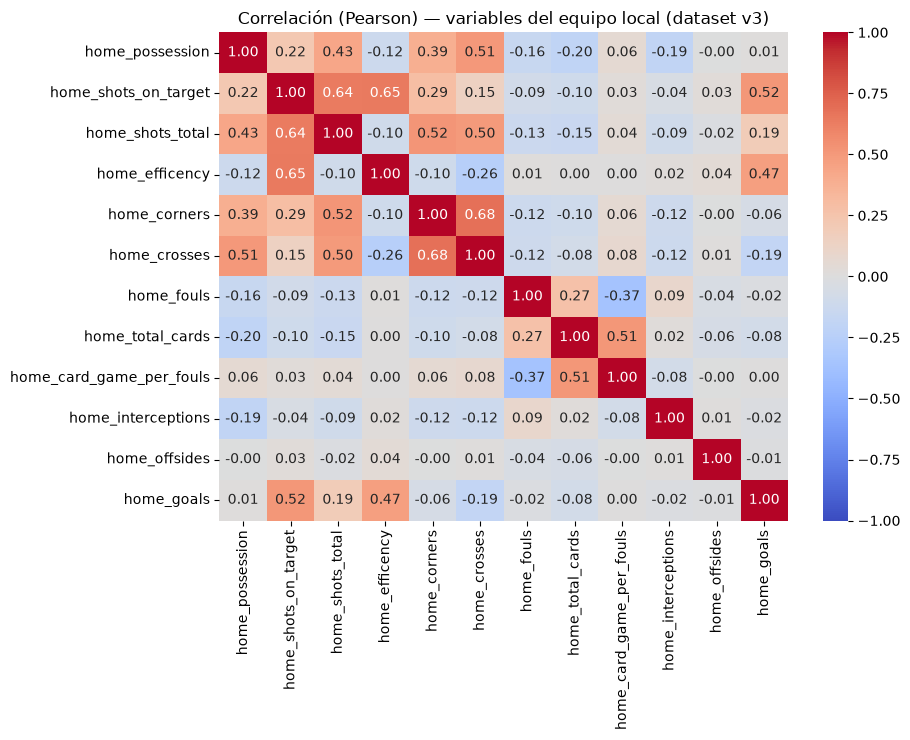

In [9]:
# Matriz de correlación (Pearson) entre variables numéricas continuas/conteo

import matplotlib.pyplot as plt
import seaborn as sns

vars_corr = [
    "home_possession", "home_shots_on_target", "home_shots_total", "home_efficency",
    "home_corners", "home_crosses", "home_fouls", "home_total_cards",
    "home_card_game_per_fouls", "home_interceptions", "home_offsides", "home_goals",
]

corr = df[vars_corr].corr(method="pearson")

plt.figure(figsize=(9.5, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlación (Pearson) — variables del equipo local (dataset v3)")
plt.tight_layout()
plt.show()

## Lectura rápida

- El dataset queda con **2,102 partidos** (7 temporadas, 2020-21 a lo jugado del Apertura 2026) y sin duplicados; las únicas columnas con datos faltantes son las que dependen de que `score` se haya podido interpretar, o de secciones de estadística ausentes en el reporte original (ver celda de faltantes arriba).
- Posesión local+visitante cuadra ~100% en la enorme mayoría de partidos (revisar arriba si aparece
  algún caso con desviación grande — puede ser error de scraping puntual).
- `home_team`, `referee`, `venue` son nominales de alta cardinalidad: no van directo a una matriz de
  correlación; para eso se necesita un proxy ordinal (como se hizo en el notebook 12 con
  `dureza_arbitro`/`propension_equipos`).

## Siguiente paso

Este es un primer corte descriptivo. A partir de aquí podemos avanzar, según lo que interese revisar
primero:

1. **Home/away splits**: comparar distribución de cada métrica entre local y visitante (boxplots o
   test de medias) — es la base del "efecto localía" que ya se exploró parcialmente en el notebook 12.
2. **Perfiles por equipo**: ya se hizo en el notebook 15 con el histórico de 5 temporadas; falta
   extenderlo a las 7 temporadas actuales (con Atlante como equipo nuevo).
3. **Matriz policórica** de variables ordinales (terciles) para complementar esta correlación Pearson.
4. Conectar este dataset limpio con el pipeline del notebook 12 y volver a correr el protocolo
   árbitro-vs-equipos con el histórico completo.

Lo definimos juntos según hacia dónde quieras llevar el análisis.

## Matriz policórica (variables originales del dataset v3, home y away a la par)

A diferencia de la matriz Pearson de arriba, aquí discretizamos cada variable numérica en terciles
(Bajo/Medio/Alto) y calculamos correlación **policórica** (Olsson 1979: umbrales a partir de las
proporciones marginales + máxima verosimilitud sobre una normal bivariada) — el método correcto
para variables ordinales, a diferencia de Pearson que asume continuidad.

Esta vez incluimos **local y visitante lado a lado** (cada métrica aparece dos veces seguidas:
`home_x`, `away_x`) para poder comparar directamente si el patrón de correlaciones es simétrico
entre jugar de local o de visitante, más la severidad del árbitro y la propensión de cada equipo
(local y visitante) a recibir tarjetas.

### Corrección: `card_game_per_fouls` mezclaba tarjetas de ambos equipos

Como viste en la matriz anterior, `home_card_game_per_fouls`/`away_card_game_per_foul` (las columnas
que armaste en Numbers) usan `total_game_cards` (tarjetas de **ambos** equipos) como numerador,
dividido solo entre las faltas de un equipo — por eso `home_card_game_per_fouls` correlacionaba más
fuerte con `away_total_cards` que con `home_total_cards`. No es un error de datos, solo una
definición distinta a "qué tan caro le sale a ESTE equipo cada falta que comete".

Para la matriz de correlación construimos una versión corregida, puramente por equipo:
`home_card_per_foul_propio = home_total_cards / home_fouls` (y análogo para away) — así cada
variable solo refleja las tarjetas que recibe ese mismo equipo por sus propias faltas.

In [10]:
df["home_card_per_foul_propio"] = df["home_total_cards"] / df["home_fouls"].replace(0, np.nan)
df["away_card_per_foul_propio"] = df["away_total_cards"] / df["away_fouls"].replace(0, np.nan)

df[["home_total_cards", "home_fouls", "home_card_game_per_fouls", "home_card_per_foul_propio"]].head(5)

,home_total_cards,home_fouls,home_card_game_per_fouls,home_card_per_foul_propio
0,1,14,0.142857,0.071429
1,2,14,0.428571,0.142857
2,1,14,0.142857,0.071429
3,4,20,0.350000,0.200000
4,1,19,0.105263,0.052632


### Nota metodológica: por qué no se usa un ID arbitrario para `referee`/`team`

`referee` (45 valores tras consolidar duplicados) y `home_team`/`away_team` (19 valores, incluye a Atlante desde su ascenso en 2026-2027) son **nominales** — sin orden natural
entre ellos. Un identificador arbitrario (alfabético, o por orden de aparición) **no sirve** para la
matriz policórica: el método asume que los niveles reflejan una escala continua subyacente real, y
un ID alfabético no tiene ningún significado ordinal.

Lo que sí es válido — y es lo que ya usamos en el notebook 14 — es convertir ambos en un **proxy
ordinal con significado real**, usando la misma métrica para que sean comparables entre sí:

- `arbitro_dureza` = promedio histórico de `total_game_cards` en los partidos que ha pitado ese árbitro.
- `home_team_propension` / `away_team_propension` = promedio histórico de tarjetas que recibe ese
  equipo (combinando sus partidos de local y de visita), evaluado por separado según si en *este*
  partido específico juega de local o de visitante.

Los tres quedan en la misma escala conceptual ("¿qué tan tarjetero es este factor?"), lo que permite
comparar de forma justa cuánto pesa el árbitro frente a cuánto pesa cada equipo.

In [11]:
from scipy.stats import norm, multivariate_normal
from scipy.optimize import minimize_scalar
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

def a_terciles(serie):
    return pd.qcut(serie.rank(method="first"), 3, labels=[0, 1, 2]).astype(int)

def umbrales(conteos):
    proporciones = np.cumsum(conteos) / conteos.sum()
    z = norm.ppf(proporciones[:-1])
    return np.concatenate([[-8.0], z, [8.0]])

def prob_rectangulo(mvn, x0, x1, y0, y1):
    return mvn.cdf([x1, y1]) - mvn.cdf([x0, y1]) - mvn.cdf([x1, y0]) + mvn.cdf([x0, y0])

def correlacion_policorica(x, y):
    tabla = pd.crosstab(x, y).values
    umbral_x = umbrales(tabla.sum(axis=1))
    umbral_y = umbrales(tabla.sum(axis=0))
    def neg_log_verosimilitud(r):
        mvn = multivariate_normal(mean=[0, 0], cov=[[1, r], [r, 1]])
        ll = 0.0
        for i in range(tabla.shape[0]):
            for j in range(tabla.shape[1]):
                if tabla[i, j] == 0:
                    continue
                p = prob_rectangulo(mvn, umbral_x[i], umbral_x[i + 1], umbral_y[j], umbral_y[j + 1])
                ll -= tabla[i, j] * np.log(max(p, 1e-12))
        return ll
    resultado = minimize_scalar(neg_log_verosimilitud, bounds=(-0.999, 0.999), method="bounded")
    return resultado.x

# Proxy ordinal para referee: severidad histórica (promedio de total_game_cards en sus partidos)
df["arbitro_dureza"] = df.groupby("referee")["total_game_cards"].transform("mean")

# Proxy ordinal para team (local y visitante): propensión histórica a recibir tarjetas,
# combinando su historial como local y como visitante (formato largo, misma métrica que el árbitro)
largo_propension = pd.concat([
    df[["home_team", "home_total_cards"]].rename(columns={"home_team": "team", "home_total_cards": "tarjetas"}),
    df[["away_team", "away_total_cards"]].rename(columns={"away_team": "team", "away_total_cards": "tarjetas"}),
])
propension_equipo = largo_propension.groupby("team")["tarjetas"].mean()
df["home_team_propension"] = df["home_team"].map(propension_equipo)
df["away_team_propension"] = df["away_team"].map(propension_equipo)

# Variables home/away a la par (cada métrica aparece dos veces seguidas: home_x, away_x)
variables_originales = [
    "home_possession", "away_possession",
    "home_shots_on_target", "away_shots_on_target",
    "home_shots_total", "away_shots_total",
    "home_efficency", "away_efficency",
    "home_corners", "away_corners",
    "home_crosses", "away_crosses",
    "home_fouls", "away_fouls",
    "home_total_cards", "away_total_cards",
    "home_card_per_foul_propio", "away_card_per_foul_propio",
    "home_interceptions", "away_interceptions",
    "home_offsides", "away_offsides",
    "home_goals", "away_goals",
    "arbitro_dureza", "home_team_propension", "away_team_propension",
]

df_valido = df.dropna(subset=variables_originales).copy()
print(f"Partidos usados (sin nulos en ninguna de las {len(variables_originales)} variables): {len(df_valido)} de {len(df)}")

terciles = {v: a_terciles(df_valido[v]) for v in variables_originales}

matriz = pd.DataFrame(1.0, index=variables_originales, columns=variables_originales)
for a, b in combinations(variables_originales, 2):
    r = correlacion_policorica(terciles[a], terciles[b])
    matriz.loc[a, b] = r
    matriz.loc[b, a] = r

matriz.round(3)

Partidos usados (sin nulos en ninguna de las 27 variables): 1986 de 2102


,home_possession,away_possession,home_shots_on_target,away_shots_on_target,home_shots_total,away_shots_total,home_efficency,away_efficency,home_corners,away_corners,home_crosses,away_crosses,home_fouls,away_fouls,home_total_cards,away_total_cards,home_card_per_foul_propio,away_card_per_foul_propio,home_interceptions,away_interceptions,home_offsides,away_offsides,home_goals,away_goals,arbitro_dureza,home_team_propension,away_team_propension
home_possession,1.000,-0.999,0.208,-0.220,0.448,-0.436,-0.150,0.108,0.367,-0.393,0.529,-0.511,-0.172,0.142,-0.181,0.132,-0.134,0.093,-0.208,0.200,0.002,-0.023,-0.026,0.052,0.002,-0.221,0.198
away_possession,-0.999,1.000,-0.197,0.225,-0.440,0.434,0.151,-0.106,-0.362,0.397,-0.519,0.512,0.166,-0.146,0.182,-0.129,0.138,-0.093,0.205,-0.206,0.007,0.031,0.049,-0.039,-0.003,0.225,-0.196
home_shots_on_target,0.208,-0.197,1.000,-0.074,0.623,-0.171,0.707,0.018,0.307,-0.097,0.133,-0.079,-0.123,-0.077,-0.059,0.090,-0.041,0.137,-0.086,-0.031,0.052,0.026,0.548,0.040,0.049,-0.156,0.108
away_shots_on_target,-0.220,0.225,-0.074,1.000,-0.145,0.664,-0.007,0.700,-0.059,0.293,-0.097,0.195,-0.092,-0.018,0.157,-0.027,0.188,-0.067,0.024,-0.058,0.061,0.105,0.081,0.532,0.032,0.130,-0.100
home_shots_total,0.448,-0.440,0.623,-0.145,1.000,-0.321,-0.129,0.072,0.519,-0.273,0.496,-0.342,-0.113,-0.036,-0.109,0.107,-0.098,0.147,-0.133,0.051,0.001,0.007,0.187,0.026,0.009,-0.116,0.103
away_shots_total,-0.436,0.434,-0.171,0.664,-0.321,1.000,0.051,-0.024,-0.254,0.486,-0.302,0.494,-0.018,-0.024,0.130,-0.141,0.137,-0.158,0.142,-0.057,-0.037,0.020,-0.016,0.260,0.016,0.155,-0.135
home_efficency,-0.150,0.151,0.707,-0.007,-0.129,0.051,1.000,-0.056,-0.087,0.100,-0.293,0.192,-0.006,-0.037,-0.000,-0.006,-0.012,0.021,0.032,-0.068,0.051,-0.010,0.480,-0.011,0.057,-0.076,0.012
away_efficency,0.108,-0.106,0.018,0.700,0.072,-0.024,-0.056,1.000,0.123,-0.103,0.160,-0.228,-0.040,0.104,0.019,0.053,0.036,0.002,-0.034,0.043,0.056,0.044,0.016,0.472,-0.020,-0.001,-0.066
home_corners,0.367,-0.362,0.307,-0.059,0.519,-0.254,-0.087,0.123,1.000,-0.267,0.658,-0.370,-0.142,-0.067,-0.050,0.082,-0.047,0.115,-0.130,0.069,0.026,0.018,-0.013,0.088,0.028,-0.093,0.074
away_corners,-0.393,0.397,-0.097,0.293,-0.273,0.486,0.100,-0.103,-0.267,1.000,-0.380,0.677,-0.016,-0.091,0.072,-0.118,0.085,-0.137,0.103,-0.131,0.037,0.068,0.103,-0.006,-0.011,0.110,-0.083


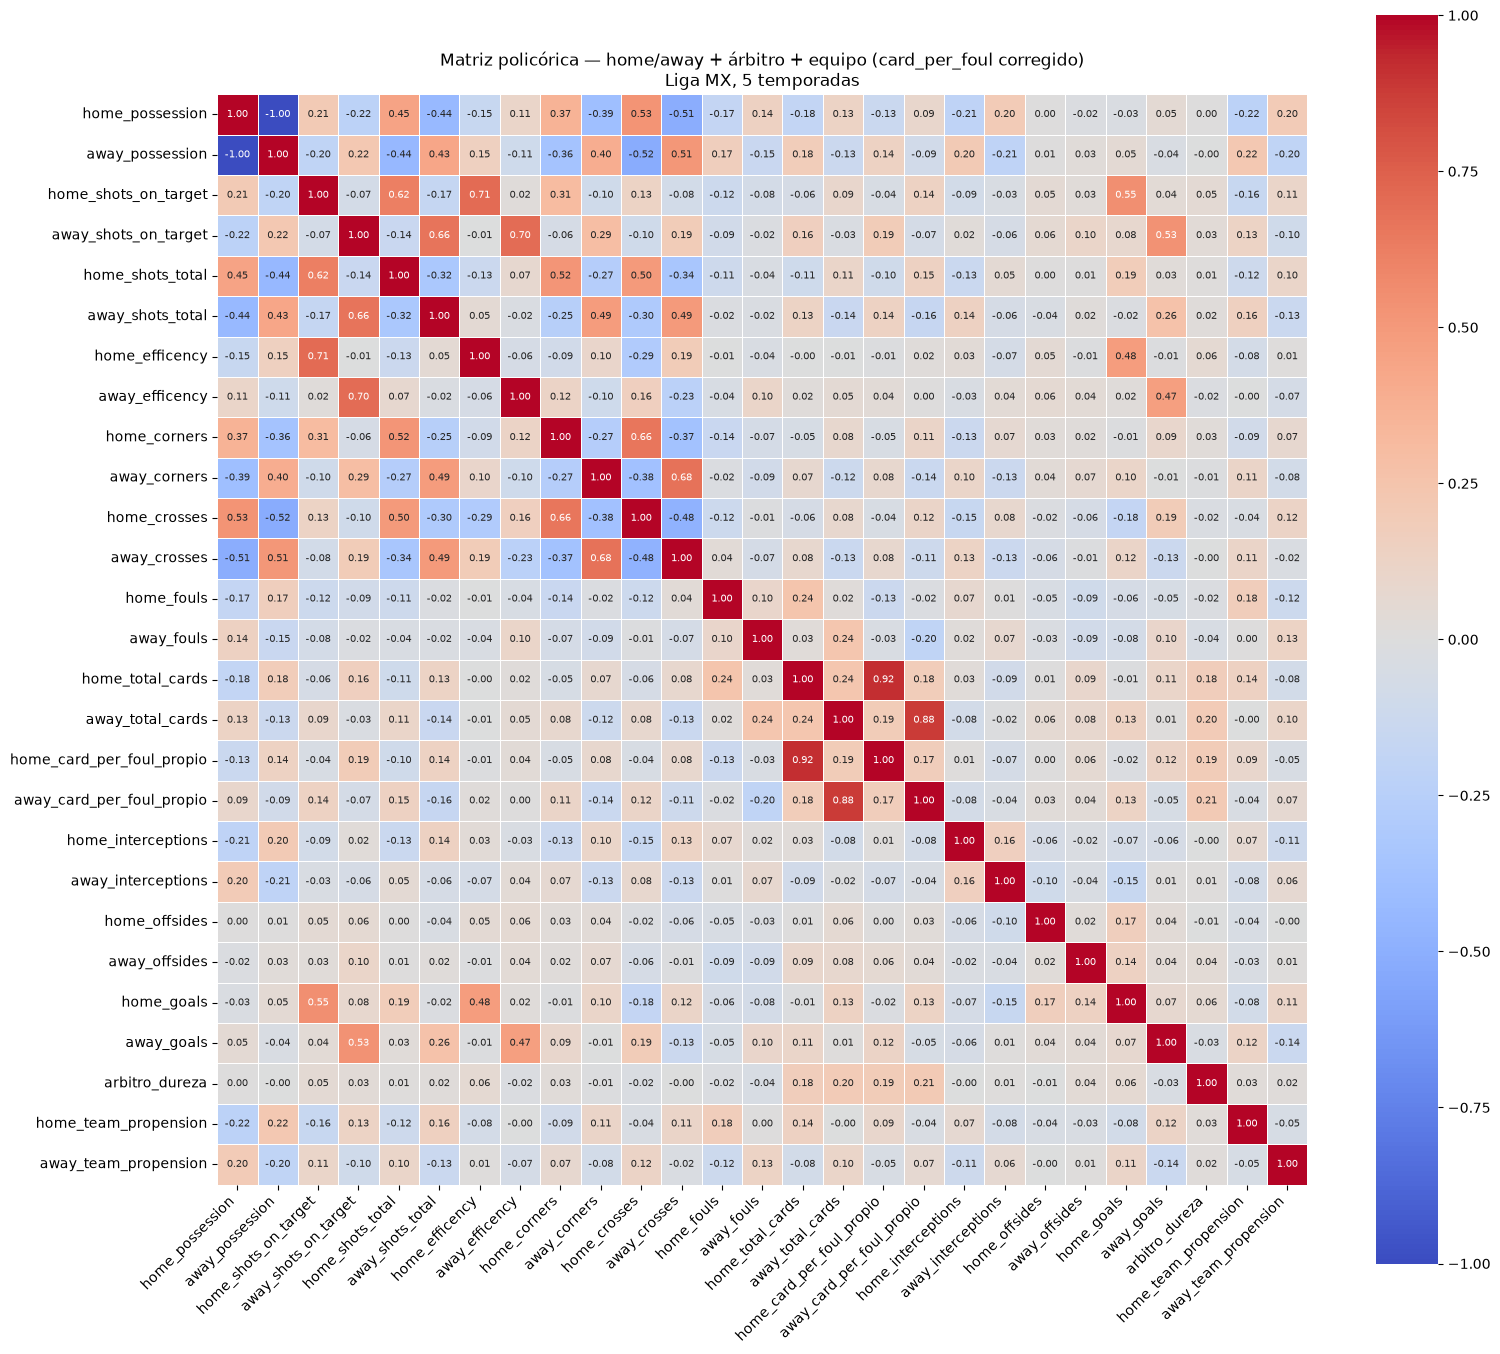

In [12]:
plt.figure(figsize=(16, 14))
sns.heatmap(matriz.astype(float), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, annot_kws={"size": 7})
plt.title("Matriz policórica — home/away + árbitro + equipo (card_per_foul corregido)\nLiga MX, 5 temporadas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/tmp/matriz_policorica_v3_corregida_ligamx.png", dpi=150)
plt.show()